In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import FunctionTransformer

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer



In [5]:
df = pd.read_csv('./Dataset/airbus_crash_passengers.csv', usecols = ['Age','Fare','Survived'])

In [7]:
df.head()

,Survived,Age,Fare
0,1,36.0,104.30
1,0,28.3,116.58
2,1,37.8,24.50
3,0,48.3,136.86
4,0,27.2,89.96


In [9]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
# To check if the distribution is normal or not, use QQ plot or pd.skew()

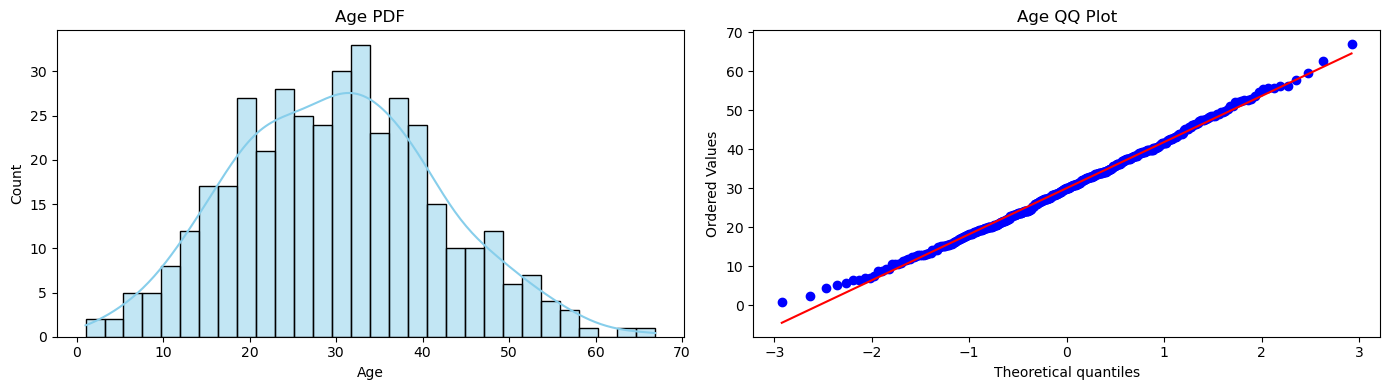

In [19]:

plt.figure(figsize=(14, 4))

# PDF / Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(X_train['Age'], kde=True, color='skyblue', bins=30)
plt.title('Age PDF')

# QQ Plot
plt.subplot(1, 2, 2)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.tight_layout()
plt.show()

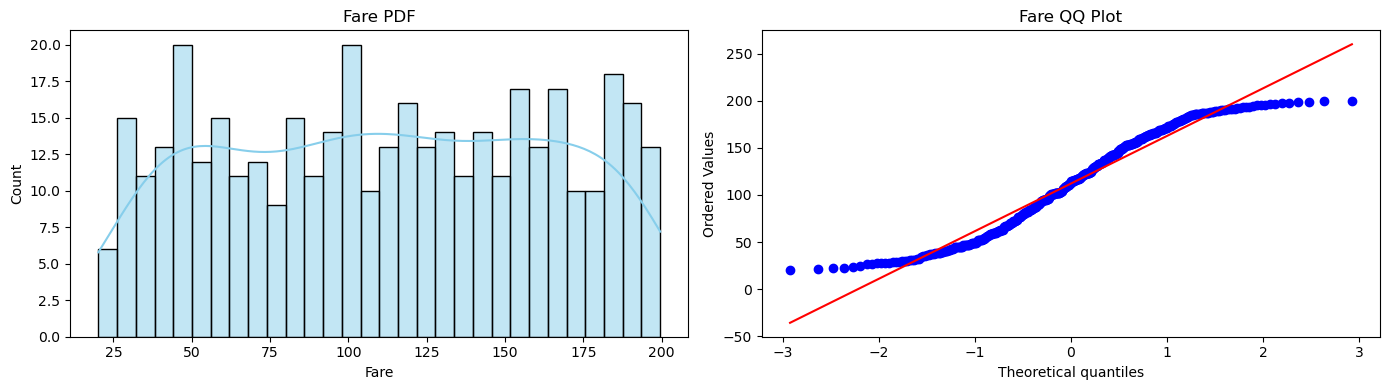

In [21]:

plt.figure(figsize=(14, 4))

# PDF / Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(X_train['Fare'], kde=True, color='skyblue', bins=30)
plt.title('Fare PDF')

# QQ Plot
plt.subplot(1, 2, 2)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.tight_layout()
plt.show()

In [23]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [25]:
clf1.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred1 = clf1.predict(X_test)
y_pred2 = clf2.predict(X_test)

print("Accuracy of clf1", accuracy_score(y_test, y_pred1))
print("Accuracy of clf2", accuracy_score(y_test, y_pred2))

Accuracy of clf1 0.55
Accuracy of clf2 0.5


In [27]:
trf = FunctionTransformer(func = np.log1p)

In [32]:
X_train_transform = trf.fit_transform(X_train)
X_test_transform = trf.transform(X_test)

In [40]:
clf3 = LogisticRegression()
clf4 = DecisionTreeClassifier()

clf3.fit(X_train_transform, y_train)
clf4.fit(X_train_transform, y_train)

y_pred3 = clf3.predict(X_test_transform)
y_pred4 = clf4.predict(X_test_transform)

print("Accuracy of clf3", accuracy_score(y_test, y_pred3))
print("Accuracy of clf4", accuracy_score(y_test, y_pred4))

Accuracy of clf3 0.59
Accuracy of clf4 0.5


In [46]:
X_transform = trf.fit_transform(X)

clf5 = LogisticRegression()
clf6 = DecisionTreeClassifier()

print('LR', np.mean(cross_val_score(clf5, X_transform,y,scoring = 'accuracy', cv = 10)))
print('DT', np.mean(cross_val_score(clf6, X_transform,y,scoring = 'accuracy', cv = 10)))

LR 0.53
DT 0.534


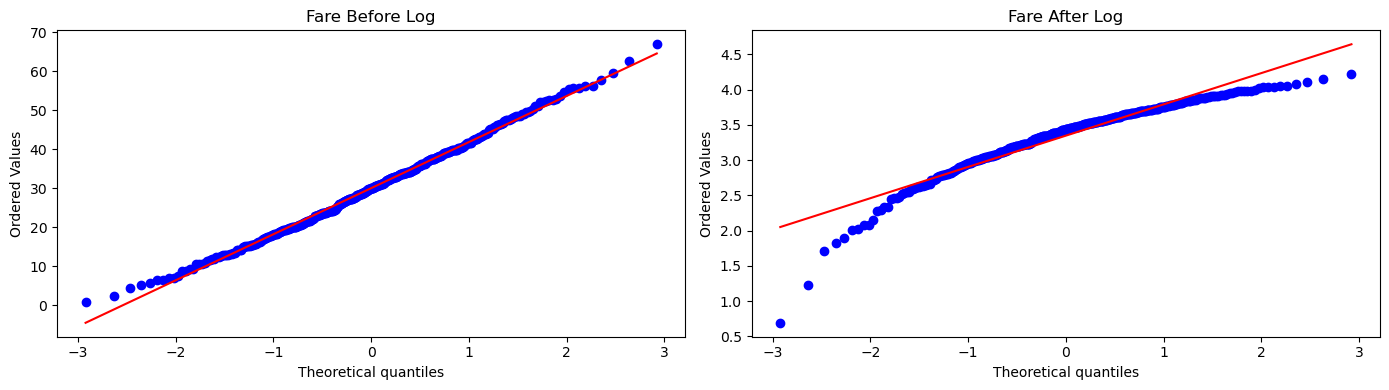

In [50]:

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Fare Before Log')

# QQ Plot
plt.subplot(1, 2, 2)
stats.probplot(X_train_transform['Age'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.tight_layout()
plt.show()

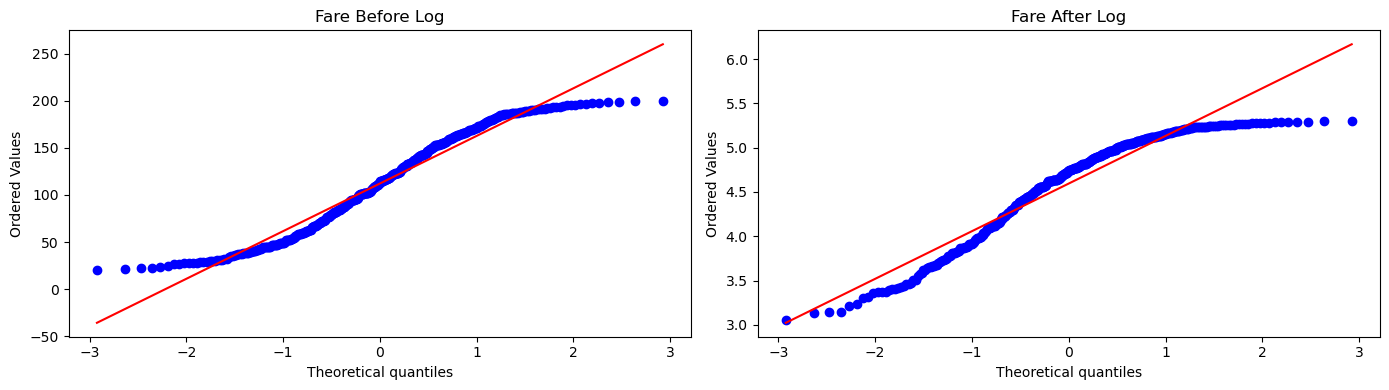

In [52]:

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

# QQ Plot
plt.subplot(1, 2, 2)
stats.probplot(X_train_transform['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.tight_layout()
plt.show()

In [66]:
trf2 = ColumnTransformer([
    ('Fare_trans',FunctionTransformer(np.log1p),['Fare'])
], remainder = 'passthrough')

X_train_transform1 = trf2.fit_transform(X_train)
X_test_transform1 = trf2.transform(X_test)

In [68]:
clf6 = LogisticRegression()
clf7 = DecisionTreeClassifier()

clf6.fit(X_train_transform1, y_train)
clf7.fit(X_train_transform1, y_train)

y_pred6 = clf6.predict(X_test_transform1)
y_pred7 = clf7.predict(X_test_transform1)

print("Accuracy of clf3", accuracy_score(y_test, y_pred6))
print("Accuracy of clf4", accuracy_score(y_test, y_pred7))

Accuracy of clf3 0.61
Accuracy of clf4 0.51
